In [ ]:
import cv2

image = cv2.imread('/content/55.PNG')
print("Image loaded successfully. Shape:", image.shape)

Image loaded successfully. Shape: (1327, 1353, 3)


## Preprocess Image

### Subtask:
Convert the image to grayscale, apply an inverse binary threshold to isolate curves, and use morphological erosion to handle thick lines, ensuring each distinct shape has a clear contour for hierarchy detection.


**Reasoning**:
I will convert the loaded image to grayscale, apply an inverse binary threshold to highlight the curves, and then use morphological erosion to thin the lines, preparing the image for accurate contour detection as per the instructions.



In [ ]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)) # Using a 3x3 kernel as 5x5 might erode too much
eroded_image = cv2.erode(thresh_image, kernel, iterations=1)

print("Image converted to grayscale.")
print("Inverse binary threshold applied.")
print("Morphological erosion applied.")

Image converted to grayscale.
Inverse binary threshold applied.
Morphological erosion applied.


## Find Contours

### Subtask:
Detect all closed contours in the preprocessed binary image using `cv2.findContours` with `cv2.RETR_TREE` to capture their hierarchical relationships and `cv2.CHAIN_APPROX_SIMPLE` to approximate contour points.


**Reasoning**:
To detect contours and their hierarchical relationships, I will use `cv2.findContours` on the `eroded_image` with `cv2.RETR_TREE` and `cv2.CHAIN_APPROX_SIMPLE` as specified. After detection, I will print the total number of contours and the shape of the hierarchy array to confirm the output.



In [ ]:
contours, hierarchy = cv2.findContours(eroded_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print(f"Total contours found: {len(contours)}")
print(f"Hierarchy array shape: {hierarchy.shape}")

Total contours found: 54
Hierarchy array shape: (1, 54, 4)


## Build Tree-like Data Structure

### Subtask:
Process the `hierarchy` array to create a more intuitive, tree-like data structure that represents the parent-child relationships of the contours. This structure should allow for easy traversal and understanding of the nesting levels.

**Reasoning**:
To build a tree-like data structure, I need to define a function that takes the `hierarchy` array as input and converts it into a more navigable format. This function will create nodes for each contour and establish parent-child relationships based on the hierarchy data.



In [ ]:
def build_contour_tree(hierarchy):
    tree_nodes = []
    # Hierarchy is a (1, N, 4) array, where N is the number of contours
    # Each row is [Next, Previous, First_Child, Parent]
    hierarchy = hierarchy[0] # Get rid of the extra dimension

    for i, h_entry in enumerate(hierarchy):
        node = {
            "contour_idx": i,
            "next": h_entry[0],
            "previous": h_entry[1],
            "first_child": h_entry[2],
            "parent": h_entry[3],
            "children": [] # To be populated later
        }
        tree_nodes.append(node)

    # Populate children lists and calculate depth
    for i, node in enumerate(tree_nodes):
        if node["parent"] != -1:
            tree_nodes[node["parent"]]["children"].append(i)

    # Calculate depths using a recursive helper function
    contour_depths = {}
    def calculate_depth(node_idx, current_depth):
        contour_depths[node_idx] = current_depth
        for child_idx in tree_nodes[node_idx]["children"]:
            calculate_depth(child_idx, current_depth + 1)

    # Find root contours (those with no parent) and start depth calculation
    root_contours = [i for i, node in enumerate(tree_nodes) if node["parent"] == -1]
    for root_idx in root_contours:
        calculate_depth(root_idx, 0)

    return tree_nodes, contour_depths

In [ ]:
def merge_contour_pairs(tree_nodes, contour_depths):
    """
    Merge outer and inner contours into logical regions and
    ensure the result is a single rooted tree via a virtual root.
    """

    merged_nodes = []
    contour_to_merged = {}
    visited = set()

    # ---- Step 1: merge outer + inner pairs ----
    for idx, node in enumerate(tree_nodes):
        if idx in visited:
            continue

        depth = contour_depths[idx]

        if depth % 2 == 0:
            children = node["children"]

            if len(children) == 1 and contour_depths[children[0]] == depth + 1:
                inner_idx = children[0]
                visited.add(inner_idx)
            else:
                inner_idx = None

            merged_idx = len(merged_nodes)
            merged_nodes.append({
                "outer_contour": idx,
                "inner_contour": inner_idx,
                "children": []
            })

            contour_to_merged[idx] = merged_idx
            if inner_idx is not None:
                contour_to_merged[inner_idx] = merged_idx

            visited.add(idx)

    # ---- Step 2: reconnect children between merged nodes ----
    for region in merged_nodes:
        source = (
            region["inner_contour"]
            if region["inner_contour"] is not None
            else region["outer_contour"]
        )

        for child in tree_nodes[source]["children"]:
            if child in contour_to_merged:
                child_region = contour_to_merged[child]
                if child_region != contour_to_merged[source]:
                    region["children"].append(child_region)

    # ---- Step 3: inject virtual root ----
    all_children = set()
    for node in merged_nodes:
        all_children.update(node["children"])

    root_regions = [
        i for i in range(len(merged_nodes))
        if i not in all_children
    ]

    virtual_root = {
        "outer_contour": None,
        "inner_contour": None,
        "children": root_regions
    }

    # shift indices by +1
    for node in merged_nodes:
        node["children"] = [c + 1 for c in node["children"]]

    merged_tree = [virtual_root] + merged_nodes
    merged_tree[0]["children"] = [r + 1 for r in root_regions]

    return merged_tree

In [ ]:
def compute_merged_depths(merged_tree):
    depths = {}

    def dfs(node_idx, depth):
        depths[node_idx] = depth
        for child in merged_tree[node_idx]["children"]:
            dfs(child, depth + 1)

    dfs(0, 0)  # virtual root
    return depths

In [ ]:
tree_nodes, contour_depths = build_contour_tree(hierarchy)
merged_tree = merge_contour_pairs(tree_nodes, contour_depths)
merged_depths = compute_merged_depths(merged_tree)

print(f"Raw contours: {len(tree_nodes)}")
print(f"Merged regions: {len(merged_tree)}")

Raw contours: 54
Merged regions: 28


## Visualize Contours with Hierarchy

### Subtask:
Visualize the detected contours on the original image, drawing each contour and labeling it with its index and hierarchical depth. This will provide a clear visual representation of the nested structure found.


**Reasoning**:
To visualize the contours with their hierarchy, I will draw each contour on a copy of the original image, calculate the centroid of each contour to place text, and then add labels indicating the contour's index and its calculated depth.



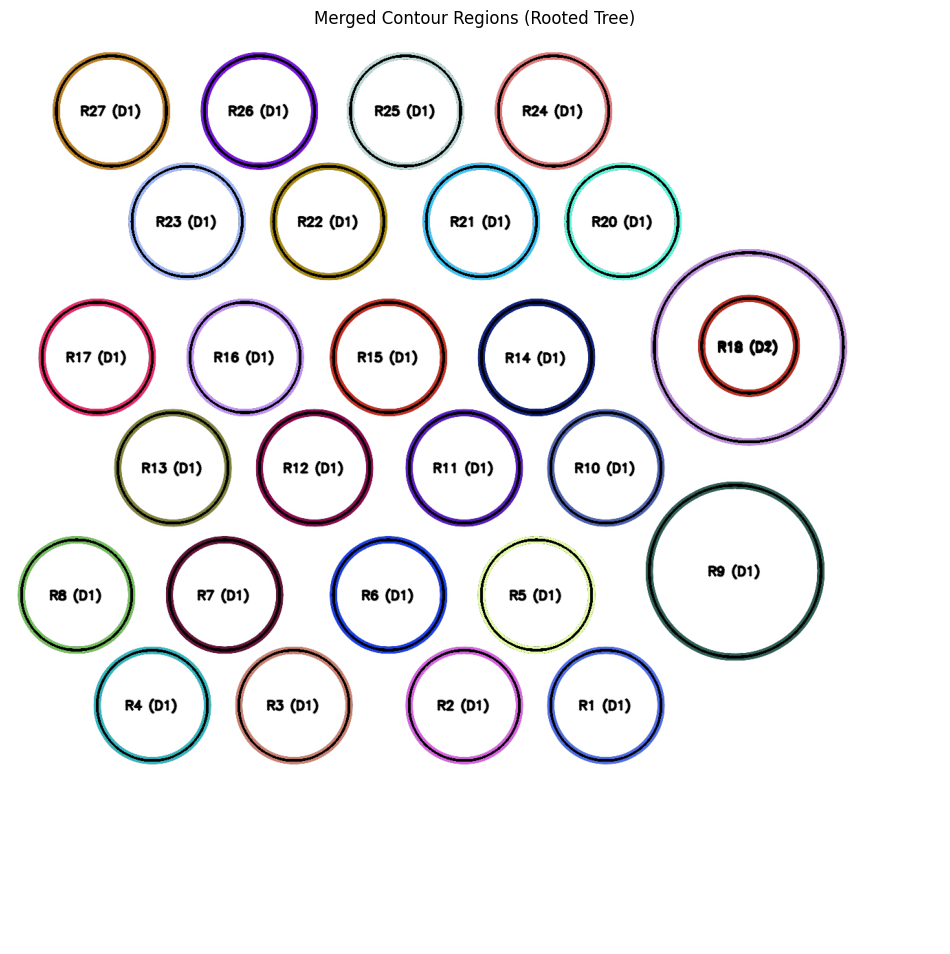

Visualized merged contour regions with region index and rooted tree depth.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Create a copy of the original image to draw on
output_image = image.copy()

# Font settings
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.6
font_thickness = 2
text_color = (0, 0, 0)

# Iterate through merged regions (skip virtual root at index 0)
for region_idx in range(1, len(merged_tree)):
    region = merged_tree[region_idx]

    color = (
        int(np.random.randint(0, 255)),
        int(np.random.randint(0, 255)),
        int(np.random.randint(0, 255))
    )

    outer_idx = region["outer_contour"]
    inner_idx = region["inner_contour"]

    # Draw outer contour
    if outer_idx is not None:
        cv2.drawContours(output_image, contours, outer_idx, color, 2)

    # Draw inner contour if it exists
    if inner_idx is not None:
        cv2.drawContours(output_image, contours, inner_idx, color, 2)

    # Label placement: centroid of outer contour
    if outer_idx is None:
        continue

    contour = contours[outer_idx]
    M = cv2.moments(contour)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        depth = merged_depths.get(region_idx, -1)
        label = f"R{region_idx} (D{depth})"

        text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]
        text_x = cx - text_size[0] // 2
        text_y = cy + text_size[1] // 2

        cv2.putText(
            output_image,
            label,
            (text_x, text_y),
            font,
            font_scale,
            text_color,
            font_thickness,
            cv2.LINE_AA
        )

# Convert BGR → RGB for matplotlib
output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(output_image_rgb)
plt.title("Merged Contour Regions (Rooted Tree)")
plt.axis("off")
plt.show()

print("Visualized merged contour regions with region index and rooted tree depth.")

## Summarize Hierarchical Structure

### Subtask:
Summarize the detected hierarchical structure of the nested curves based on the `tree_nodes` and `contour_depths` data. Describe the main root contours and their children/grandchildren relationships.


**Reasoning**:
To summarize the hierarchical structure, I will iterate through the `tree_nodes` to identify root contours (parent = -1) and then recursively explore their children to describe the nesting levels and relationships as indicated by `contour_depths`.



In [ ]:
print("Merged Region Hierarchical Structure Summary:")

# Identify root regions (those that are not children of any other region)
all_children = set()
for node in merged_tree:
    all_children.update(node["children"])

root_region_indices = [
    i for i in range(len(merged_tree))
    if i not in all_children
]

def describe_region(region_idx, indent=0):
    region = merged_tree[region_idx]
    depth = merged_depths.get(region_idx, -1)

    outer = region["outer_contour"]
    inner = region["inner_contour"]

    contour_info = (
        f"outer=C{outer}, inner=C{inner}"
        if inner is not None
        else f"outer=C{outer}"
    )

    description = (
        "  " * indent
        + f"- Region R{region_idx} (Depth: {depth}, {contour_info})"
    )
    print(description)

    for child_idx in region["children"]:
        describe_region(child_idx, indent + 1)


if not root_region_indices:
    print("No root regions found. This indicates an unusual merged hierarchy.")
else:
    print(f"Total {len(root_region_indices)} root regions identified.")
    for root_idx in root_region_indices:
        print(f"\nRoot Region R{root_idx}:")
        describe_region(root_idx, indent=0)

print("\nMerged hierarchy summary complete.")

Merged Region Hierarchical Structure Summary:
Total 1 root regions identified.

Root Region R0:
- Region R0 (Depth: 0, outer=CNone)
  - Region R1 (Depth: 1, outer=C0, inner=C1)
  - Region R2 (Depth: 1, outer=C2, inner=C3)
  - Region R3 (Depth: 1, outer=C4, inner=C5)
  - Region R4 (Depth: 1, outer=C6, inner=C7)
  - Region R5 (Depth: 1, outer=C8, inner=C9)
  - Region R6 (Depth: 1, outer=C10, inner=C11)
  - Region R7 (Depth: 1, outer=C12, inner=C13)
  - Region R8 (Depth: 1, outer=C14, inner=C15)
  - Region R9 (Depth: 1, outer=C16, inner=C17)
  - Region R10 (Depth: 1, outer=C18, inner=C19)
  - Region R11 (Depth: 1, outer=C20, inner=C21)
  - Region R12 (Depth: 1, outer=C22, inner=C23)
  - Region R13 (Depth: 1, outer=C24, inner=C25)
  - Region R14 (Depth: 1, outer=C26, inner=C27)
  - Region R15 (Depth: 1, outer=C28, inner=C29)
  - Region R16 (Depth: 1, outer=C30, inner=C31)
  - Region R17 (Depth: 1, outer=C32, inner=C33)
  - Region R18 (Depth: 1, outer=C34, inner=C35)
    - Region R19 (Depth

In [ ]:
def tree_to_edges(merged_tree):
    """
    Convert a rooted tree into n-1 (parent, child) edges.
    """
    edges = []

    for parent_idx, node in enumerate(merged_tree):
        for child_idx in node["children"]:
            edges.append((parent_idx, child_idx))

    return edges

In [ ]:
%%capture
!apt-get update && apt-get install -y graphviz graphviz-dev && pip install pygraphviz

In [ ]:
edges = tree_to_edges(merged_tree)

for u, v in edges:
    print(u, v)

0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
18 19


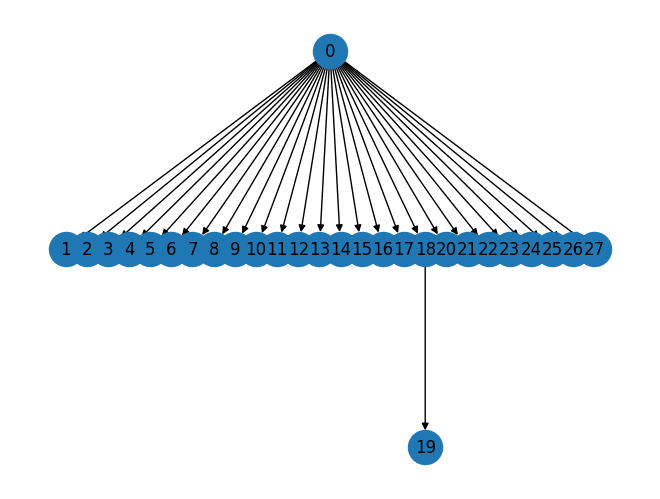

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(edges)
pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

nx.draw(G, pos, with_labels=True, node_size=600)
plt.show()